In [2]:
"""
Stochastic Optimization Under Bayesian Uncertainty: 4 Paradigms
================================================================

Problem: SteelCo Widget Production (Newsvendor with fixed setup cost)
- Decide production quantity q BEFORE observing demand
- 200 posterior predictive demand scenarios from a Bayesian model
- Mixed-integer: binary setup decision + continuous quantity

Paradigms implemented:
  1. Deterministic (mean-value)
  2. Stochastic Programming (SAA - Sample Average Approximation)
  3. Mean-CVaR (risk-averse)
  4. Expected Utility (exponential / CARA)

Libraries: numpy, scipy.optimize, matplotlib
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar, minimize
from dataclasses import dataclass

# ─── Reproducible Bayesian Posterior Predictive Scenarios ─────────────────────
# Simulates output of a Normal-Gamma conjugate model fitted to 24 months of
# sales data. Each draw: sample (μ, σ) from posterior, then demand ~ N(μ, σ²).

rng = np.random.default_rng(42)

N_SCENARIOS = 200
mu_posterior = rng.normal(loc=1020, scale=45, size=N_SCENARIOS)
sigma_posterior = np.abs(rng.normal(loc=150, scale=30, size=N_SCENARIOS))
demand_scenarios = np.maximum(0, rng.normal(loc=mu_posterior, scale=sigma_posterior))
demand_scenarios = np.round(demand_scenarios).astype(int)
demand_scenarios.sort()


# ─── Problem Parameters ──────────────────────────────────────────────────────

@dataclass
class ProblemParams:
    sell_price: float = 80.0       # revenue per unit sold
    unit_cost: float = 35.0        # variable production cost
    salvage_price: float = 10.0    # recovery per unsold unit
    lost_sale_penalty: float = 25.0  # goodwill cost per unmet unit
    fixed_setup: float = 5000.0    # fixed cost if production > 0
    capacity: int = 1800           # max production

P = ProblemParams()

# Derived economics
MARGIN = P.sell_price - P.unit_cost          # $45/unit sold
OVERAGE_LOSS = P.unit_cost - P.salvage_price  # $25/unit excess
UNDERAGE_LOSS = MARGIN + P.lost_sale_penalty   # $70/unit shortage
CRITICAL_RATIO = UNDERAGE_LOSS / (UNDERAGE_LOSS + OVERAGE_LOSS)  # 0.7368


# ─── Profit Function ─────────────────────────────────────────────────────────
# Vectorized: q is scalar, d can be array of scenarios

def profit(q: float, d: np.ndarray) -> np.ndarray:
    """
    Compute profit for production quantity q and demand realization(s) d.

    Profit = revenue + salvage - production_cost - setup - lost_sales
           = sell_price * min(q,d) + salvage * max(q-d,0)
             - unit_cost * q - setup * 1{q>0} - penalty * max(d-q,0)
    """
    d = np.asarray(d, dtype=float)
    scalar_input = d.ndim == 0
    d = np.atleast_1d(d)
    sold = np.minimum(q, d)
    excess = np.maximum(q - d, 0)
    shortage = np.maximum(d - q, 0)

    result = (
        P.sell_price * sold
        + P.salvage_price * excess
        - P.unit_cost * q
        - P.fixed_setup * (q > 0)
        - P.lost_sale_penalty * shortage
    )
    return float(result[0]) if scalar_input else result


def profit_breakdown(q: float, scenarios: np.ndarray) -> dict:
    """Average P&L breakdown across scenarios."""
    sold = np.minimum(q, scenarios)
    excess = np.maximum(q - scenarios, 0)
    shortage = np.maximum(scenarios - q, 0)

    return {
        "revenue": np.mean(P.sell_price * sold),
        "salvage": np.mean(P.salvage_price * excess),
        "prod_cost": P.unit_cost * q + P.fixed_setup * (q > 0),
        "lost_sales": np.mean(P.lost_sale_penalty * shortage),
        "avg_sold": np.mean(sold),
        "avg_excess": np.mean(excess),
        "avg_shortage": np.mean(shortage),
        "expected_profit": np.mean(profit(q, scenarios)),
    }


def service_level(q: float, scenarios: np.ndarray) -> float:
    """Fraction of scenarios where demand is fully met."""
    return np.mean(scenarios <= q)


# ─── CVaR Computation ────────────────────────────────────────────────────────

def cvar(profits_array: np.ndarray, alpha: float = 0.10) -> float:
    """
    CVaR at level alpha = expected profit in the worst alpha-fraction of outcomes.
    For alpha=0.10, this is the mean of the bottom 10% of profit realizations.
    """
    sorted_profits = np.sort(profits_array)
    cutoff = int(np.ceil(alpha * len(sorted_profits)))
    return np.mean(sorted_profits[:cutoff])


# ─── Exponential Utility ─────────────────────────────────────────────────────

def exp_utility(x: np.ndarray, rho: float) -> np.ndarray:
    """
    Exponential (CARA) utility: U(x) = -exp(-x / rho)

    Properties:
    - Concave → risk averse
    - Constant Absolute Risk Aversion = 1/rho
    - rho → ∞: converges to risk-neutral (linear utility)
    - rho → 0: extreme risk aversion (worst-case)
    """
    return -np.exp(-x / rho)


def certainty_equivalent(profits_array: np.ndarray, rho: float) -> float:
    """
    CE = U⁻¹(E[U(X)]) = -rho * ln(-E[U(X)])

    The guaranteed profit you'd accept instead of the lottery.
    Gap between E[profit] and CE is the risk premium.
    """
    eu = np.mean(exp_utility(profits_array, rho))
    return -rho * np.log(-eu)


# =============================================================================
# PARADIGM 1: DETERMINISTIC (MEAN-VALUE)
# =============================================================================
# Collapse the posterior to its mean and solve a single-point optimization.
# This is what you'd do with SLSQP on a scalar demand estimate.

def solve_deterministic(scenarios: np.ndarray) -> dict:
    """
    max_q  Profit(q, d̄)   where d̄ = E[demand]

    Uses scipy.optimize.minimize_scalar on the negative profit (since scipy
    minimizes). The setup cost creates a discontinuity at q=0, so we solve
    the continuous problem for q>0 and compare with q=0.
    """
    d_mean = np.mean(scenarios)

    # For q > 0: profit is concave piecewise-linear in q → unimodal
    # scipy minimize_scalar with bounded method works well here
    result = minimize_scalar(
        lambda q: -profit(q, d_mean),
        bounds=(1, P.capacity),
        method="bounded"
    )
    q_star = int(round(float(result.x)))
    profit_at_mean = profit(q_star, d_mean)

    # Compare with q = 0 (don't produce)
    profit_zero = profit(0, d_mean)
    if profit_zero > profit_at_mean:
        q_star = 0

    # TRUE expected profit: evaluate this q against ALL scenarios
    scenario_profits = profit(q_star, scenarios)
    true_expected_profit = np.mean(scenario_profits)

    return {
        "method": "Deterministic (Mean-Value)",
        "q": q_star,
        "mean_demand": d_mean,
        "profit_at_mean": float(profit(q_star, d_mean)),
        "expected_profit": true_expected_profit,
        "service_level": service_level(q_star, scenarios),
        "breakdown": profit_breakdown(q_star, scenarios),
        "profit_distribution": scenario_profits,
    }


# =============================================================================
# PARADIGM 2: STOCHASTIC PROGRAMMING (SAA)
# =============================================================================
# Sample Average Approximation: maximize the expected profit over all scenarios.
# This is the natural bridge between Bayesian posteriors and optimization.
# Each MCMC draw becomes a scenario with probability 1/N.

def solve_saa(scenarios: np.ndarray) -> dict:
    """
    max_q  (1/N) Σᵢ Profit(q, ξⁱ)

    The SAA objective is piecewise-linear and concave in q (for fixed scenarios).
    minimize_scalar finds the optimum efficiently. For a true mixed-integer
    formulation, you'd use Pyomo + Gurobi; here the only integer aspect is
    the setup decision, which we handle by comparing q>0 vs q=0.
    """
    result = minimize_scalar(
        lambda q: -np.mean(profit(q, scenarios)),
        bounds=(1, P.capacity),
        method="bounded"
    )
    q_star = int(round(float(result.x)))

    # Fine-tune: check neighbors (rounding may miss the optimum)
    candidates = [max(0, q_star - 1), q_star, min(P.capacity, q_star + 1), 0]
    best_q = max(candidates, key=lambda q: np.mean(profit(q, scenarios)))

    scenario_profits = profit(best_q, scenarios)

    return {
        "method": "Stochastic Programming (SAA)",
        "q": best_q,
        "expected_profit": np.mean(scenario_profits),
        "service_level": service_level(best_q, scenarios),
        "breakdown": profit_breakdown(best_q, scenarios),
        "profit_distribution": scenario_profits,
    }


# =============================================================================
# PARADIGM 3: MEAN-CVaR
# =============================================================================
# Maximize a weighted combination of expected profit and CVaR (tail risk).
# CVaR₁₀% = expected profit in the worst 10% of scenarios.
#
# The Rockafellar-Uryasev (2000) insight: CVaR can be computed via an
# auxiliary variable, making it LP-compatible. Here we use direct computation
# since we have discrete scenarios.

def solve_mean_cvar(
    scenarios: np.ndarray,
    alpha: float = 0.10,
    lam: float = 0.50,
) -> dict:
    """
    max_q  (1-λ)·E[Profit(q,ξ)] + λ·CVaR_α[Profit(q,ξ)]

    Parameters:
        alpha: tail fraction (0.10 = worst 10%)
        lam: weight on CVaR (0 = risk-neutral SAA, 1 = pure tail optimization)
    """
    def objective(q):
        pf = profit(q, scenarios)
        expected = np.mean(pf)
        cvar_val = cvar(pf, alpha)
        return -((1 - lam) * expected + lam * cvar_val)

    result = minimize_scalar(objective, bounds=(1, P.capacity), method="bounded")
    q_star = int(round(float(result.x)))

    # Fine-tune
    candidates = [max(0, q_star - 1), q_star, min(P.capacity, q_star + 1), 0]
    best_q = max(candidates, key=lambda q: -objective(q))

    scenario_profits = profit(best_q, scenarios)

    return {
        "method": f"Mean-CVaR (α={alpha}, λ={lam})",
        "q": best_q,
        "expected_profit": np.mean(scenario_profits),
        "cvar_10pct": cvar(scenario_profits, alpha),
        "service_level": service_level(best_q, scenarios),
        "breakdown": profit_breakdown(best_q, scenarios),
        "profit_distribution": scenario_profits,
        "alpha": alpha,
        "lambda": lam,
    }


# =============================================================================
# PARADIGM 4: EXPECTED UTILITY (EXPONENTIAL / CARA)
# =============================================================================
# Maximize E[U(Profit)] where U(x) = -exp(-x/ρ).
# This is the von Neumann-Morgenstern framework — the theoretical foundation
# for all of decision theory under uncertainty.
#
# Key properties:
# - ρ large → risk-neutral → converges to SAA
# - ρ small → risk-averse → stocks more to avoid catastrophic shortages
# - Certainty Equivalent (CE) = guaranteed profit equivalent to the gamble
# - Risk Premium = E[Profit] - CE (what you'd pay to eliminate uncertainty)
# - For Normal profits: CE ≈ E[Profit] - Var[Profit]/(2ρ) (mean-variance)

def solve_expected_utility(
    scenarios: np.ndarray,
    rho: float = 20000,
) -> dict:
    """
    max_q  (1/N) Σᵢ U(Profit(q, ξⁱ))   where U(x) = -exp(-x/ρ)

    Parameters:
        rho: risk tolerance (higher = less risk averse)
             Interpretation: you're indifferent between a sure $0 and a
             50/50 gamble of +ρ·ln(2) vs -ρ·ln(2) ≈ ±0.693·ρ
    """
    def objective(q):
        pf = profit(q, scenarios)
        return -np.mean(exp_utility(pf, rho))  # minimize negative expected utility

    result = minimize_scalar(objective, bounds=(1, P.capacity), method="bounded")
    q_star = int(round(float(result.x)))

    # Fine-tune
    candidates = [max(0, q_star - 1), q_star, min(P.capacity, q_star + 1), 0]
    best_q = max(candidates, key=lambda q: -objective(q))

    scenario_profits = profit(best_q, scenarios)
    ce = certainty_equivalent(scenario_profits, rho)
    ep = np.mean(scenario_profits)

    return {
        "method": f"Expected Utility (ρ={rho:,})",
        "q": best_q,
        "expected_profit": ep,
        "certainty_equivalent": ce,
        "risk_premium": ep - ce,
        "service_level": service_level(best_q, scenarios),
        "breakdown": profit_breakdown(best_q, scenarios),
        "profit_distribution": scenario_profits,
        "rho": rho,
    }


# =============================================================================
# DIAGNOSTIC METRICS
# =============================================================================

def compute_wait_and_see(scenarios: np.ndarray) -> float:
    """
    Wait-and-See (WS): expected profit with perfect information.
    For each scenario, find the optimal q, then average.
    This is the upper bound — what a crystal ball would be worth.
    """
    ws_profits = []
    for d in scenarios:
        # Optimal q for known demand d: produce exactly d (if profitable)
        best_q = 0
        best_p = profit(0, d)
        # Check q = d (sell everything, no excess, no shortage)
        p_d = profit(d, d)
        if p_d > best_p:
            best_q, best_p = d, p_d
        ws_profits.append(best_p)
    return np.mean(ws_profits)


def compute_diagnostics(det_result, saa_result, scenarios):
    """VSS and EVPI — the two key diagnostic metrics."""
    ws = compute_wait_and_see(scenarios)
    vss = saa_result["expected_profit"] - det_result["expected_profit"]
    evpi = ws - saa_result["expected_profit"]
    return {"VSS": vss, "EVPI": evpi, "WS": ws}


# =============================================================================
# SOLVE ALL & DISPLAY
# =============================================================================

def print_results(results: list[dict], diagnostics: dict):
    """Print a formatted comparison table."""
    print("=" * 88)
    print("STEELCO WIDGET PRODUCTION — OPTIMIZATION UNDER BAYESIAN UNCERTAINTY")
    print("=" * 88)
    print(f"\nScenarios: {N_SCENARIOS} posterior predictive draws")
    print(f"Demand:    mean={np.mean(demand_scenarios):.0f}, "
          f"std={np.std(demand_scenarios):.0f}, "
          f"range=[{demand_scenarios.min()}, {demand_scenarios.max()}]")
    print(f"\nEconomics: margin=${MARGIN}/unit, "
          f"overage=${OVERAGE_LOSS}/unit, "
          f"underage=${UNDERAGE_LOSS}/unit")
    print(f"Critical ratio: {CRITICAL_RATIO:.4f} "
          f"→ stock to {CRITICAL_RATIO*100:.1f}th percentile")

    print(f"\n{'─' * 88}")
    print(f"{'Method':<32} {'q':>5} {'E[Profit]':>11} {'Revenue':>10} "
          f"{'Lost$':>8} {'SL%':>6} {'Worst10%':>10}")
    print(f"{'─' * 88}")

    for r in results:
        bk = r["breakdown"]
        t10 = cvar(r["profit_distribution"], 0.10)
        print(
            f"{r['method']:<32} {r['q']:>5} "
            f"${r['expected_profit']:>9,.0f} "
            f"${bk['revenue']:>8,.0f} "
            f"${bk['lost_sales']:>6,.0f} "
            f"{r['service_level']*100:>5.1f}% "
            f"${t10:>8,.0f}"
        )

    print(f"{'─' * 88}")
    print(f"\n{'DIAGNOSTICS':}")
    print(f"  Wait-and-See (perfect info):  ${diagnostics['WS']:>10,.0f}")
    print(f"  Stochastic optimum (SAA):     ${results[1]['expected_profit']:>10,.0f}")
    print(f"  Deterministic (mean-value):   ${results[0]['expected_profit']:>10,.0f}")
    print(f"  ────────────────────────────────────────")
    print(f"  VSS (value of stochastic soln): ${diagnostics['VSS']:>8,.0f}  "
          f"← extra profit from using scenarios")
    print(f"  EVPI (value of perfect info):   ${diagnostics['EVPI']:>8,.0f}  "
          f"← max value of better forecasting")
    print(f"  Inequality: EEV ≤ SP ≤ WS  →  "
          f"${results[0]['expected_profit']:,.0f} ≤ "
          f"${results[1]['expected_profit']:,.0f} ≤ "
          f"${diagnostics['WS']:,.0f}  ✓")


# =============================================================================
# VISUALIZATION
# =============================================================================

def plot_results(results: list[dict], diagnostics: dict, scenarios: np.ndarray):
    """Generate a comprehensive 4-panel visualization."""
    plt.style.use("dark_background")
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.patch.set_facecolor("#0f1117")
    for ax in axes.flat:
        ax.set_facecolor("#161b22")
    fig.suptitle(
        "SteelCo Widget Production: Optimization Under Bayesian Uncertainty",
        fontsize=14, fontweight="bold", y=0.98, color="white",
    )
    colors = ["#e6960c", "#16a34a", "#9333ea", "#ca8a04"]
    labels = [r["method"].split("(")[0].strip() for r in results]

    # ── Panel 1: Profit distributions ─────────────────────────────────────
    ax = axes[0, 0]
    for i, r in enumerate(results):
        ax.hist(
            r["profit_distribution"], bins=30, alpha=0.45,
            color=colors[i], label=f"{labels[i]} (q={r['q']})",
            edgecolor="white", linewidth=0.3,
        )
        ax.axvline(
            r["expected_profit"], color=colors[i],
            linestyle="--", linewidth=1.5, alpha=0.8,
        )
    ax.set_xlabel("Profit ($)")
    ax.set_ylabel("Frequency")
    ax.set_title("Profit Distributions Across 200 Scenarios")
    ax.legend(fontsize=8, loc="upper left")

    # ── Panel 2: Expected profit bar chart with breakdown ─────────────────
    ax = axes[0, 1]
    x = np.arange(len(results))
    width = 0.6
    ep_vals = [r["expected_profit"] for r in results]
    bars = ax.bar(x, ep_vals, width, color=colors, alpha=0.8, edgecolor="white")

    # Add worst-10% markers
    for i, r in enumerate(results):
        t10 = cvar(r["profit_distribution"], 0.10)
        ax.plot(i, t10, "v", color="red", markersize=8, zorder=5)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8, rotation=15, ha="right")
    ax.set_ylabel("Profit ($)")
    ax.set_title("Expected Profit & Worst-10% (▼)")

    # Add WS line
    ax.axhline(diagnostics["WS"], color="gray", linestyle=":", linewidth=1, alpha=0.7)
    ax.text(
        len(results) - 0.5, diagnostics["WS"] + 200,
        f"Wait-and-See: ${diagnostics['WS']:,.0f}",
        fontsize=7, color="gray", ha="right",
    )

    # ── Panel 3: P&L waterfall for SAA vs Deterministic ───────────────────
    ax = axes[1, 0]
    categories = ["Revenue", "Salvage", "Prod Cost", "Lost Sales", "Profit"]
    det_bk = results[0]["breakdown"]
    saa_bk = results[1]["breakdown"]

    det_vals = [det_bk["revenue"], det_bk["salvage"], -det_bk["prod_cost"],
                -det_bk["lost_sales"], det_bk["expected_profit"]]
    saa_vals = [saa_bk["revenue"], saa_bk["salvage"], -saa_bk["prod_cost"],
                -saa_bk["lost_sales"], saa_bk["expected_profit"]]

    x = np.arange(len(categories))
    width = 0.35
    ax.bar(x - width / 2, det_vals, width, label=f"Deterministic (q={results[0]['q']})",
           color=colors[0], alpha=0.7, edgecolor="white")
    ax.bar(x + width / 2, saa_vals, width, label=f"SAA (q={results[1]['q']})",
           color=colors[1], alpha=0.7, edgecolor="white")
    ax.axhline(0, color="white", linewidth=0.5, alpha=0.3)
    ax.set_xticks(x)
    ax.set_xticklabels(categories, fontsize=9)
    ax.set_ylabel("$ (avg across scenarios)")
    ax.set_title("P&L Breakdown: Deterministic vs SAA")
    ax.legend(fontsize=8)

    # ── Panel 4: Utility curve + sensitivity to ρ ─────────────────────────
    ax = axes[1, 1]

    # Show utility curves for different ρ values
    profit_range = np.linspace(
        min(r["profit_distribution"].min() for r in results) - 2000,
        max(r["profit_distribution"].max() for r in results) + 2000,
        200,
    )

    rho_values = [8_000, 20_000, 50_000, 200_000]
    rho_colors = ["#ef4444", "#f59e0b", "#22c55e", "#60a5fa"]
    for rho_val, rc in zip(rho_values, rho_colors):
        u_vals = exp_utility(profit_range, rho_val)
        ax.plot(
            profit_range, u_vals,
            color=rc, linewidth=1.5, alpha=0.8,
            label=f"ρ={rho_val:,}",
        )

    # Linear reference
    u_linear = exp_utility(profit_range, 1e9)
    ax.plot(profit_range, u_linear, ":", color="gray", linewidth=1, alpha=0.6,
            label="Risk-neutral")

    ax.set_xlabel("Profit ($)")
    ax.set_ylabel("U(Profit)")
    ax.set_title("Exponential Utility: U(x) = −exp(−x/ρ)")
    ax.legend(fontsize=8, loc="lower right")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    return fig


def plot_rho_sensitivity(scenarios: np.ndarray):
    """Show how optimal stock, expected profit, and CE change with ρ."""
    plt.style.use("dark_background")
    rho_range = np.logspace(np.log10(3000), np.log10(500000), 40)
    qs, eps, ces, rps = [], [], [], []

    for rho in rho_range:
        r = solve_expected_utility(scenarios, rho=rho)
        qs.append(r["q"])
        eps.append(r["expected_profit"])
        ces.append(r["certainty_equivalent"])
        rps.append(r["risk_premium"])

    # SAA reference
    saa = solve_saa(scenarios)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    fig.patch.set_facecolor("#0f1117")
    for ax in axes.flat:
        ax.set_facecolor("#161b22")
    fig.suptitle(
        "Expected Utility: Sensitivity to Risk Tolerance ρ",
        fontsize=13, fontweight="bold",
    )

    # Panel 1: Optimal stock
    ax = axes[0]
    ax.semilogx(rho_range, qs, "o-", color="#ca8a04", markersize=3, linewidth=1.5)
    ax.axhline(saa["q"], color="#16a34a", linestyle="--", linewidth=1, alpha=0.7)
    ax.text(rho_range[-1], saa["q"] + 5, f"SAA q={saa['q']}", fontsize=8,
            color="#16a34a", ha="right")
    ax.set_xlabel("Risk tolerance ρ (log scale)")
    ax.set_ylabel("Optimal stock q")
    ax.set_title("Stock Decision vs Risk Tolerance")

    # Panel 2: Expected profit & CE
    ax = axes[1]
    ax.semilogx(rho_range, eps, "s-", color="#16a34a", markersize=3,
                linewidth=1.5, label="E[Profit]")
    ax.semilogx(rho_range, ces, "^-", color="#ca8a04", markersize=3,
                linewidth=1.5, label="Certainty Equiv.")
    ax.fill_between(rho_range, ces, eps, alpha=0.15, color="#ca8a04",
                    label="Risk premium")
    ax.set_xlabel("Risk tolerance ρ (log scale)")
    ax.set_ylabel("$ value")
    ax.set_title("Expected Profit vs Certainty Equivalent")
    ax.legend(fontsize=8)

    # Panel 3: Risk premium
    ax = axes[2]
    ax.semilogx(rho_range, rps, "D-", color="#9333ea", markersize=3, linewidth=1.5)
    ax.set_xlabel("Risk tolerance ρ (log scale)")
    ax.set_ylabel("Risk Premium ($)")
    ax.set_title("Risk Premium = E[Profit] − CE")

    plt.tight_layout()
    return fig


# =============================================================================
# MAIN
# =============================================================================

if __name__ == "__main__":
    # Solve all paradigms
    det = solve_deterministic(demand_scenarios)
    saa = solve_saa(demand_scenarios)
    mcvar = solve_mean_cvar(demand_scenarios, alpha=0.10, lam=0.50)
    eu = solve_expected_utility(demand_scenarios, rho=20_000)

    results = [det, saa, mcvar, eu]
    diagnostics = compute_diagnostics(det, saa, demand_scenarios)

    # Print comparison table
    print_results(results, diagnostics)

    # Additional utility-specific output
    print(f"\n{'─' * 88}")
    print("EXPECTED UTILITY DETAILS (ρ=20,000)")
    print(f"  Certainty equivalent:  ${eu['certainty_equivalent']:>10,.0f}")
    print(f"  Risk premium:          ${eu['risk_premium']:>10,.0f}")
    print(f"  Interpretation: SteelCo would accept a guaranteed "
          f"${eu['certainty_equivalent']:,.0f}")
    print(f"  instead of the uncertain profit stream with E={eu['expected_profit']:,.0f}")

    # Generate plots
    fig1 = plot_results(results, diagnostics, demand_scenarios)

    fig2 = plot_rho_sensitivity(demand_scenarios)

    plt.close("all")

STEELCO WIDGET PRODUCTION — OPTIMIZATION UNDER BAYESIAN UNCERTAINTY

Scenarios: 200 posterior predictive draws
Demand:    mean=1009, std=156, range=[539, 1416]

Economics: margin=$45.0/unit, overage=$25.0/unit, underage=$70.0/unit
Critical ratio: 0.7368 → stock to 73.7th percentile

────────────────────────────────────────────────────────────────────────────────────────
Method                               q   E[Profit]    Revenue    Lost$    SL%   Worst10%
────────────────────────────────────────────────────────────────────────────────────────
Deterministic (Mean-Value)        1009 $   34,668 $  75,898 $ 1,518  51.5% $  21,480
Stochastic Programming (SAA)      1098 $   35,476 $  78,452 $   720  74.0% $  19,256
Mean-CVaR (α=0.1, λ=0.5)           996 $   34,364 $  75,368 $ 1,684  47.5% $  21,806
Expected Utility (ρ=20,000)       1053 $   35,305 $  77,361 $ 1,061  66.0% $  20,380
────────────────────────────────────────────────────────────────────────────────────────

DIAGNOSTICS
  Wait-

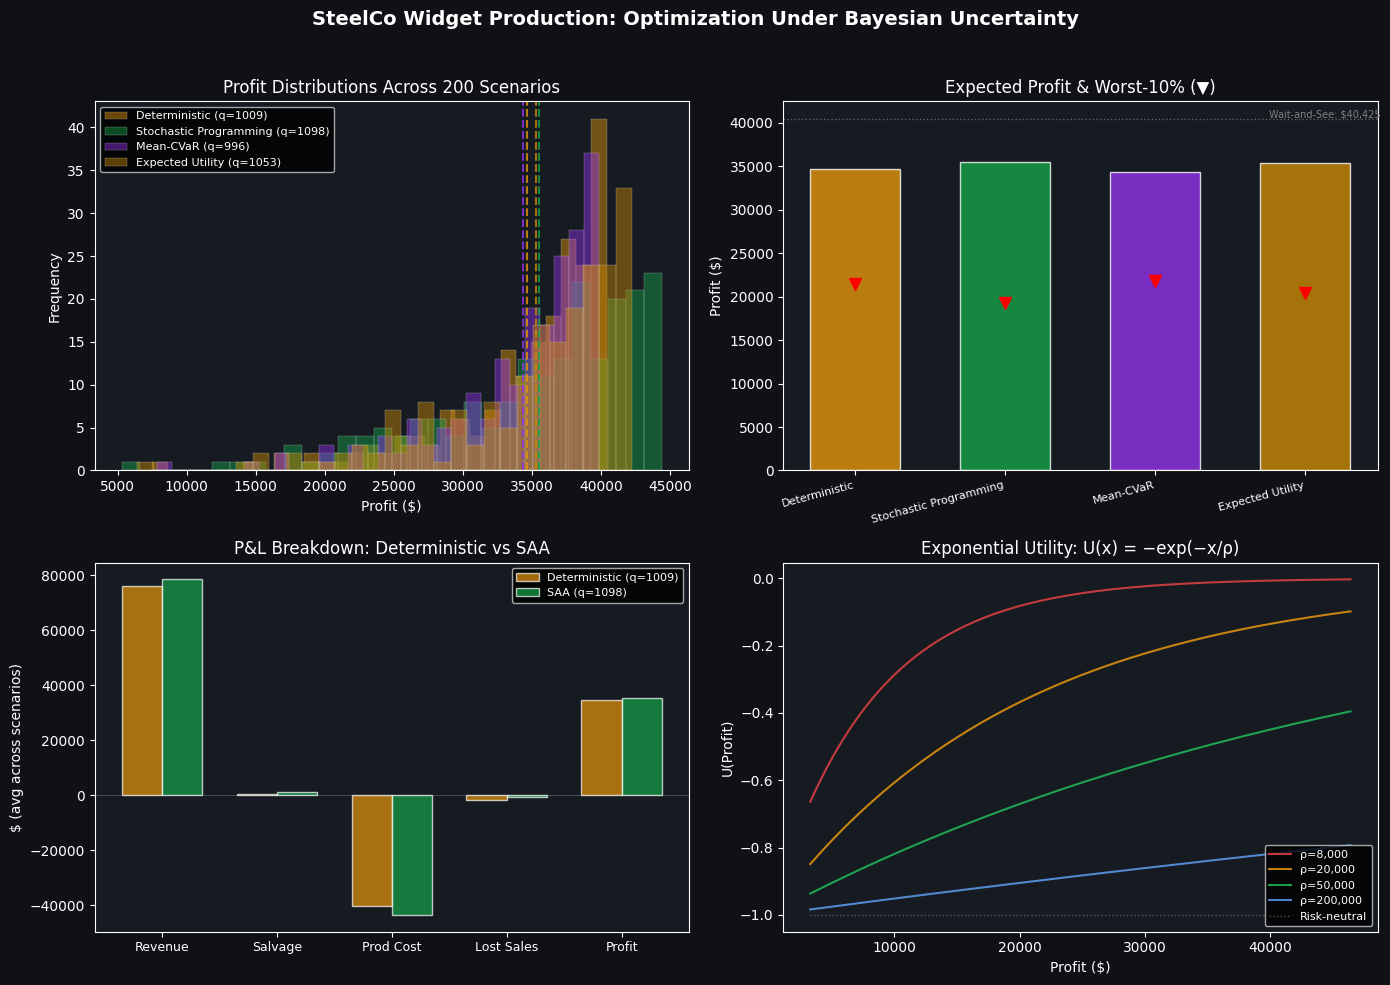

In [3]:
fig1

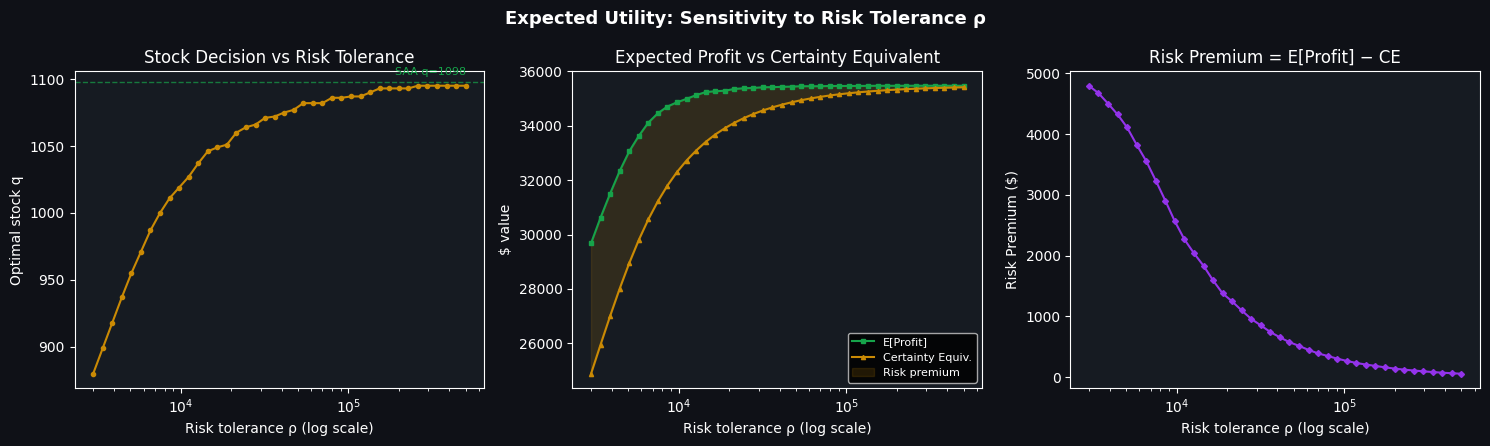

In [4]:
fig2

In [ ]:
"""
Multi-Product Stochastic Optimization Under Bayesian Uncertainty
================================================================

Extends the single-product SteelCo example to 5 products with shared
constraints (warehouse space, production budget, shared machine hours).

KEY CHANGES FROM SINGLE-PRODUCT:
  1. Decision variable: scalar q → vector q = (q₁, q₂, ..., q₅)
  2. scipy.minimize_scalar → scipy.optimize.minimize (vector) or LP solvers
  3. Constraints couple products: stocking more of A means less of B
  4. Posterior predictive scenarios carry joint correlation across products
  5. Problem size: P products × N scenarios in the extensive form

PARADIGMS:
  1. Deterministic (mean-value) with constraints
  2. SAA with constraints
  3. Mean-CVaR with constraints
  4. Expected Utility with constraints

LIBRARIES: numpy, scipy.optimize (minimize, linprog)

For production use, you would replace scipy with:
  - Pyomo + Gurobi/CPLEX/HiGHS for LP/MIP formulations (SAA, CVaR)
  - CVXPY for convex formulations (CVaR, DRO)
  - Pyomo + mpi-sppy for decomposition at scale
"""

import numpy as np
from scipy.optimize import minimize, linprog, LinearConstraint
from dataclasses import dataclass, field
import matplotlib.pyplot as plt
from typing import Optional

# =============================================================================
# PROBLEM SETUP: 5 PRODUCTS WITH SHARED CONSTRAINTS
# =============================================================================

PRODUCTS = ["Widget-A", "Widget-B", "Gadget-C", "Gizmo-D", "Doohickey-E"]
N_PRODUCTS = len(PRODUCTS)
N_SCENARIOS = 200

@dataclass
class Product:
    name: str
    sell_price: float
    unit_cost: float
    salvage_price: float
    lost_sale_penalty: float
    warehouse_space: float    # cubic meters per unit
    machine_hours: float      # hours per unit to produce
    max_production: int       # product-specific capacity

products = [
    Product("Widget-A",    sell_price=80,  unit_cost=35, salvage_price=10, lost_sale_penalty=25, warehouse_space=0.5,  machine_hours=0.10, max_production=800),
    Product("Widget-B",    sell_price=120, unit_cost=55, salvage_price=20, lost_sale_penalty=40, warehouse_space=0.8,  machine_hours=0.15, max_production=600),
    Product("Gadget-C",    sell_price=45,  unit_cost=18, salvage_price=5,  lost_sale_penalty=12, warehouse_space=0.2,  machine_hours=0.05, max_production=1500),
    Product("Gizmo-D",     sell_price=200, unit_cost=90, salvage_price=30, lost_sale_penalty=60, warehouse_space=1.5,  machine_hours=0.30, max_production=300),
    Product("Doohickey-E", sell_price=60,  unit_cost=25, salvage_price=8,  lost_sale_penalty=15, warehouse_space=0.3,  machine_hours=0.08, max_production=1000),
]

# ── Shared constraints ───────────────────────────────────────────────────────
WAREHOUSE_CAPACITY = 800    # total cubic meters
MACHINE_HOURS = 200         # total production hours available
BUDGET = 120_000            # total production budget ($)


# =============================================================================
# GENERATE CORRELATED BAYESIAN POSTERIOR PREDICTIVE SCENARIOS
# =============================================================================
# In practice, these would come from a hierarchical Bayesian model (e.g.,
# multivariate Normal with unknown mean vector and covariance, fitted via
# MCMC in PyMC/Stan/NumPyro). Here we simulate the output.
#
# KEY INSIGHT: MCMC posterior predictive draws AUTOMATICALLY capture:
#   - Parameter uncertainty (wider than plug-in estimates)
#   - Cross-product demand correlations (products that co-move)
#   - Non-Gaussian structure (fat tails, skewness)
# You don't estimate correlations separately — they're embedded in the samples.

def generate_correlated_scenarios(n_scenarios=200, seed=42):
    """
    Simulate posterior predictive demand for 5 products.
    
    Correlation structure:
    - Widget-A and Widget-B are positively correlated (substitutes in same market)
    - Gadget-C is mildly negatively correlated with A,B (different market segment)
    - Gizmo-D is independent (niche product)
    - Doohickey-E is mildly correlated with everything (general indicator)
    """
    rng = np.random.default_rng(seed)

    # Posterior mean and std for each product's demand
    mu_means = np.array([400, 300, 800, 120, 500])
    mu_stds  = np.array([ 30,  25,  50,  15,  35])  # posterior uncertainty on means

    # Demand noise std (inherent demand variability)
    sigma_means = np.array([80, 60, 120, 30, 90])

    # Correlation matrix for the MEAN parameters (posterior correlation)
    corr = np.array([
        [1.0,  0.6, -0.2,  0.0,  0.3],
        [0.6,  1.0, -0.1,  0.0,  0.25],
        [-0.2, -0.1, 1.0,  0.0,  0.15],
        [0.0,  0.0,  0.0,  1.0,  0.0],
        [0.3,  0.25, 0.15, 0.0,  1.0],
    ])

    # For each posterior draw: sample correlated means, then sample demand
    scenarios = np.zeros((n_scenarios, N_PRODUCTS))
    for i in range(n_scenarios):
        # 1. Draw correlated mean vector from posterior
        z = rng.multivariate_normal(np.zeros(N_PRODUCTS), corr)
        mu_draw = mu_means + mu_stds * z

        # 2. Draw demand from likelihood given these means
        demand = rng.normal(loc=mu_draw, scale=sigma_means)
        scenarios[i] = np.maximum(0, np.round(demand))

    return scenarios.astype(int)


demand_scenarios = generate_correlated_scenarios(N_SCENARIOS)

# Quick stats
print("DEMAND SCENARIO STATISTICS")
print(f"{'Product':<15} {'Mean':>7} {'Std':>7} {'Min':>7} {'Max':>7}")
print("─" * 45)
for j, p in enumerate(products):
    d = demand_scenarios[:, j]
    print(f"{p.name:<15} {d.mean():>7.0f} {d.std():>7.0f} {d.min():>7} {d.max():>7}")

# Correlation matrix of scenarios (should reflect the posterior structure)
print(f"\nDemand correlation matrix (from posterior predictive scenarios):")
corr_actual = np.corrcoef(demand_scenarios.T)
for i in range(N_PRODUCTS):
    row = "  ".join(f"{corr_actual[i, j]:>6.2f}" for j in range(N_PRODUCTS))
    print(f"  {products[i].name:<14} {row}")


# =============================================================================
# MULTI-PRODUCT PROFIT FUNCTION (VECTORIZED OVER SCENARIOS)
# =============================================================================

def multi_profit(q: np.ndarray, d: np.ndarray) -> np.ndarray:
    """
    Compute profit for production vector q and demand matrix d.
    
    Args:
        q: shape (P,) — production quantities for each product
        d: shape (N, P) — demand scenarios
        
    Returns:
        shape (N,) — total profit in each scenario
    """
    q = np.asarray(q, dtype=float)
    d = np.atleast_2d(d)  # (N, P)

    sold = np.minimum(q, d)                     # (N, P)
    excess = np.maximum(q - d, 0)               # (N, P)
    shortage = np.maximum(d - q, 0)             # (N, P)

    # Per-product economics (vectorized across products)
    sell_prices   = np.array([p.sell_price for p in products])
    unit_costs    = np.array([p.unit_cost for p in products])
    salvage       = np.array([p.salvage_price for p in products])
    penalties     = np.array([p.lost_sale_penalty for p in products])

    revenue = np.sum(sell_prices * sold, axis=1)            # (N,)
    salvage_rev = np.sum(salvage * excess, axis=1)          # (N,)
    prod_cost = np.sum(unit_costs * q)                      # scalar
    lost_sales = np.sum(penalties * shortage, axis=1)        # (N,)

    return revenue + salvage_rev - prod_cost - lost_sales


def multi_breakdown(q: np.ndarray, scenarios: np.ndarray) -> dict:
    """Detailed P&L breakdown per product."""
    q = np.asarray(q, dtype=float)
    sell_prices = np.array([p.sell_price for p in products])
    unit_costs  = np.array([p.unit_cost for p in products])
    salvage     = np.array([p.salvage_price for p in products])
    penalties   = np.array([p.lost_sale_penalty for p in products])

    sold = np.minimum(q, scenarios)
    excess = np.maximum(q - scenarios, 0)
    shortage = np.maximum(scenarios - q, 0)

    return {
        "revenue_by_product": np.mean(sell_prices * sold, axis=0),
        "lost_sales_by_product": np.mean(penalties * shortage, axis=0),
        "excess_by_product": np.mean(excess, axis=0),
        "total_revenue": np.mean(np.sum(sell_prices * sold, axis=1)),
        "total_lost_sales": np.mean(np.sum(penalties * shortage, axis=1)),
        "total_prod_cost": np.sum(unit_costs * q),
        "total_profit": np.mean(multi_profit(q, scenarios)),
        "service_levels": np.mean(scenarios <= q, axis=0),
    }


# =============================================================================
# CONSTRAINT FUNCTIONS
# =============================================================================
# These are what make the multi-product problem fundamentally different from
# P independent single-product problems. They COUPLE the decisions.

def warehouse_usage(q):
    """Total warehouse space consumed. Must be ≤ WAREHOUSE_CAPACITY."""
    spaces = np.array([p.warehouse_space for p in products])
    return np.dot(spaces, q)

def machine_usage(q):
    """Total machine hours consumed. Must be ≤ MACHINE_HOURS."""
    hours = np.array([p.machine_hours for p in products])
    return np.dot(hours, q)

def budget_usage(q):
    """Total production cost. Must be ≤ BUDGET."""
    costs = np.array([p.unit_cost for p in products])
    return np.dot(costs, q)

def check_feasibility(q):
    """Check all constraints and return violations."""
    violations = []
    wh = warehouse_usage(q)
    if wh > WAREHOUSE_CAPACITY + 0.01:
        violations.append(f"Warehouse: {wh:.1f} > {WAREHOUSE_CAPACITY}")
    mh = machine_usage(q)
    if mh > MACHINE_HOURS + 0.01:
        violations.append(f"Machine hrs: {mh:.1f} > {MACHINE_HOURS}")
    bg = budget_usage(q)
    if bg > BUDGET + 0.01:
        violations.append(f"Budget: ${bg:,.0f} > ${BUDGET:,}")
    for j, p in enumerate(products):
        if q[j] > p.max_production + 0.01:
            violations.append(f"{p.name}: {q[j]:.0f} > {p.max_production}")
        if q[j] < -0.01:
            violations.append(f"{p.name}: {q[j]:.0f} < 0")
    return violations


# =============================================================================
# SCIPY CONSTRAINT SETUP
# =============================================================================
# scipy.optimize.minimize needs constraints in a specific format.
# For production-grade work, Pyomo + Gurobi is far superior because:
#   - Pyomo handles integer variables (setup decisions)
#   - Gurobi exploits LP/MIP structure (simplex, branch-and-bound)
#   - mpi-sppy decomposes by scenario for parallel solving
# But scipy works for continuous relaxations and is available everywhere.

spaces = np.array([p.warehouse_space for p in products])
hours  = np.array([p.machine_hours for p in products])
costs  = np.array([p.unit_cost for p in products])
caps   = np.array([p.max_production for p in products])

# Bounds: 0 ≤ qⱼ ≤ max_production_j
bounds = [(0, p.max_production) for p in products]

# Linear constraints: Aq ≤ b
# Row 1: warehouse space
# Row 2: machine hours
# Row 3: budget
A_ub = np.vstack([spaces, hours, costs])
b_ub = np.array([WAREHOUSE_CAPACITY, MACHINE_HOURS, BUDGET])

scipy_constraints = LinearConstraint(A_ub, lb=-np.inf, ub=b_ub)


# =============================================================================
# PARADIGM 1: DETERMINISTIC (MEAN-VALUE) — CONSTRAINED
# =============================================================================

def solve_deterministic_multi(scenarios: np.ndarray) -> dict:
    """
    max_q  Profit(q, d̄)   subject to constraints
    
    where d̄ = E[demand] (vector of means across products).
    
    THIS IS WHAT CHANGES: same objective as single-product, but now
    scipy.optimize.minimize replaces minimize_scalar, and we pass
    constraint objects.
    """
    d_mean = np.mean(scenarios, axis=0)  # (P,) vector of mean demands

    def neg_profit_at_mean(q):
        return -multi_profit(q, d_mean.reshape(1, -1))[0]

    # Starting point: mean demand clipped to capacity
    q0 = np.minimum(d_mean, caps) * 0.5

    result = minimize(
        neg_profit_at_mean,
        q0,
        method="SLSQP",          # <-- Your familiar SLSQP! Now with constraints.
        bounds=bounds,
        constraints={"type": "ineq", "fun": lambda q: b_ub - A_ub @ q},
        options={"maxiter": 1000, "ftol": 1e-8},
    )

    q_star = np.round(result.x).astype(int)
    q_star = np.clip(q_star, 0, caps)

    # True expected profit: evaluate against ALL scenarios
    scenario_profits = multi_profit(q_star, scenarios)

    return {
        "method": "Deterministic (Mean-Value)",
        "q": q_star,
        "profit_at_mean": float(multi_profit(q_star, d_mean.reshape(1, -1))[0]),
        "expected_profit": np.mean(scenario_profits),
        "profit_distribution": scenario_profits,
        "breakdown": multi_breakdown(q_star, scenarios),
        "warehouse_used": warehouse_usage(q_star),
        "machine_used": machine_usage(q_star),
        "budget_used": budget_usage(q_star),
    }


# =============================================================================
# PARADIGM 2: SAA — CONSTRAINED
# =============================================================================

def solve_saa_multi(scenarios: np.ndarray) -> dict:
    """
    max_q  (1/N) Σᵢ Profit(q, ξⁱ)   subject to constraints
    
    KEY DIFFERENCE FROM SINGLE-PRODUCT:
    - The objective averages over a matrix of demands (N × P)
    - Constraints couple the products
    - We use SLSQP with gradient information
    
    For the piecewise-linear newsvendor structure, this could also be
    formulated as an LP (see the LP formulation below). scipy.optimize.minimize
    with SLSQP works but is less efficient than a proper LP solver.
    """
    def neg_expected_profit(q):
        return -np.mean(multi_profit(q, scenarios))

    # Multiple restarts to avoid local optima
    # (SLSQP finds local optima; for LP structure, linprog is exact)
    best_q, best_val = None, np.inf
    for seed in range(5):
        rng = np.random.default_rng(seed + 100)
        q0 = rng.uniform(0, 1, N_PRODUCTS) * caps * 0.5
        result = minimize(
            neg_expected_profit, q0,
            method="SLSQP", bounds=bounds,
            constraints={"type": "ineq", "fun": lambda q: b_ub - A_ub @ q},
            options={"maxiter": 2000, "ftol": 1e-10},
        )
        if result.fun < best_val:
            best_val = result.fun
            best_q = result.x

    q_star = np.round(best_q).astype(int)
    q_star = np.clip(q_star, 0, caps)

    scenario_profits = multi_profit(q_star, scenarios)

    return {
        "method": "Stochastic (SAA)",
        "q": q_star,
        "expected_profit": np.mean(scenario_profits),
        "profit_distribution": scenario_profits,
        "breakdown": multi_breakdown(q_star, scenarios),
        "warehouse_used": warehouse_usage(q_star),
        "machine_used": machine_usage(q_star),
        "budget_used": budget_usage(q_star),
    }


# =============================================================================
# SAA AS A LINEAR PROGRAM (THE "RIGHT" WAY)
# =============================================================================
# The newsvendor profit function is piecewise-linear and concave. The SAA
# problem can be reformulated as an LP by introducing auxiliary variables
# for each product × scenario combination. This is the EXTENSIVE FORM.
#
# This is what Pyomo + Gurobi would solve. Here we do it with scipy.linprog
# to show the structure explicitly.

def solve_saa_lp(scenarios: np.ndarray) -> dict:
    """
    LP formulation of the SAA newsvendor with constraints.
    
    Decision variables (for each scenario s and product j):
      q_j           : first-stage production quantity (shared across scenarios)
      sold_js       : units sold = min(q_j, d_js)
      excess_js     : unsold units = max(q_j - d_js, 0)
      shortage_js   : unmet demand = max(d_js - q_j, 0)
    
    The min/max operators are linearized via:
      sold_js    ≤ q_j
      sold_js    ≤ d_js
      excess_js  = q_j - sold_js         (excess = production - sold)
      shortage_js = d_js - sold_js        (shortage = demand - sold)
      All variables ≥ 0
    
    PROBLEM SIZE:
      Variables: P + 3·P·N  (5 + 3·5·200 = 3005 variables)
      Constraints: shared constraints + per-scenario linking
      
    This scales linearly with N. At 1000 scenarios × 50 products = 150,005 
    variables — still tractable for LP solvers but slow for scipy.linprog.
    Gurobi handles millions of variables.
    """
    N, P = scenarios.shape
    prob = 1.0 / N  # equal probability per scenario

    sell = np.array([p.sell_price for p in products])
    salv = np.array([p.salvage_price for p in products])
    ucost = np.array([p.unit_cost for p in products])
    pen = np.array([p.lost_sale_penalty for p in products])

    # Variable layout: [q (P), sold (N*P), excess (N*P), shortage (N*P)]
    n_q = P
    n_sold = N * P
    n_excess = N * P
    n_short = N * P
    n_vars = n_q + n_sold + n_excess + n_short

    # Indices
    def iq(j):       return j
    def isold(s, j): return n_q + s * P + j
    def iexc(s, j):  return n_q + n_sold + s * P + j
    def ishort(s, j): return n_q + n_sold + n_excess + s * P + j

    # ── Objective: maximize expected profit ──
    # Profit = Σ_s prob * [Σ_j (sell_j * sold_js + salv_j * excess_js
    #                            - pen_j * shortage_js)] - Σ_j ucost_j * q_j
    # linprog minimizes, so we negate.
    c_obj = np.zeros(n_vars)
    for j in range(P):
        c_obj[iq(j)] = ucost[j]  # production cost (minimized)
    for s in range(N):
        for j in range(P):
            c_obj[isold(s, j)]  = -prob * sell[j]   # revenue (negated for min)
            c_obj[iexc(s, j)]   = -prob * salv[j]   # salvage (negated)
            c_obj[ishort(s, j)] =  prob * pen[j]     # penalty (cost)

    # ── Bounds ──
    var_bounds = []
    for j in range(P):
        var_bounds.append((0, products[j].max_production))  # q_j
    for s in range(N):
        for j in range(P):
            var_bounds.append((0, None))  # sold_js
    for s in range(N):
        for j in range(P):
            var_bounds.append((0, None))  # excess_js
    for s in range(N):
        for j in range(P):
            var_bounds.append((0, None))  # shortage_js

    # ── Equality constraints ──
    # For each scenario s, product j:
    #   sold_js + excess_js = q_j           (production = sold + excess)
    #   sold_js + shortage_js = d_js        (demand = sold + shortage)

    A_eq_rows = []
    b_eq_vals = []

    for s in range(N):
        for j in range(P):
            # sold + excess = q
            row = np.zeros(n_vars)
            row[isold(s, j)] = 1
            row[iexc(s, j)] = 1
            row[iq(j)] = -1
            A_eq_rows.append(row)
            b_eq_vals.append(0)

            # sold + shortage = d
            row2 = np.zeros(n_vars)
            row2[isold(s, j)] = 1
            row2[ishort(s, j)] = 1
            A_eq_rows.append(row2)
            b_eq_vals.append(float(scenarios[s, j]))

    A_eq = np.array(A_eq_rows)
    b_eq = np.array(b_eq_vals)

    # ── Inequality constraints (shared resources) ──
    # Warehouse: Σ_j space_j * q_j ≤ WAREHOUSE_CAPACITY
    # Machine:   Σ_j hours_j * q_j ≤ MACHINE_HOURS
    # Budget:    Σ_j cost_j * q_j  ≤ BUDGET

    A_ub_rows = []
    b_ub_vals = []

    for coefs, limit in [
        ([p.warehouse_space for p in products], WAREHOUSE_CAPACITY),
        ([p.machine_hours for p in products], MACHINE_HOURS),
        ([p.unit_cost for p in products], BUDGET),
    ]:
        row = np.zeros(n_vars)
        for j in range(P):
            row[iq(j)] = coefs[j]
        A_ub_rows.append(row)
        b_ub_vals.append(limit)

    A_ub_mat = np.array(A_ub_rows)
    b_ub_vec = np.array(b_ub_vals)

    # ── Solve ──
    result = linprog(
        c_obj,
        A_ub=A_ub_mat, b_ub=b_ub_vec,
        A_eq=A_eq, b_eq=b_eq,
        bounds=var_bounds,
        method="highs",   # scipy's interface to HiGHS LP solver
        options={"presolve": True, "disp": False},
    )

    if not result.success:
        print(f"LP WARNING: {result.message}")

    q_star = np.round(result.x[:P]).astype(int)
    q_star = np.clip(q_star, 0, caps)

    scenario_profits = multi_profit(q_star, scenarios)

    return {
        "method": "SAA (LP Extensive Form)",
        "q": q_star,
        "expected_profit": np.mean(scenario_profits),
        "profit_distribution": scenario_profits,
        "breakdown": multi_breakdown(q_star, scenarios),
        "warehouse_used": warehouse_usage(q_star),
        "machine_used": machine_usage(q_star),
        "budget_used": budget_usage(q_star),
        "lp_variables": n_vars,
        "lp_constraints": len(b_eq_vals) + len(b_ub_vals),
    }


# =============================================================================
# PARADIGM 3: MEAN-CVaR — CONSTRAINED
# =============================================================================

def solve_mean_cvar_multi(
    scenarios: np.ndarray, alpha: float = 0.10, lam: float = 0.50
) -> dict:
    """
    max_q  (1-λ)·E[Profit] + λ·CVaR_α[Profit]   subject to constraints
    
    CVaR can be formulated as an LP via the Rockafellar-Uryasev trick:
      CVaR_α = max_ζ { ζ - (1/α) · E[max(ζ - Profit, 0)] }
    
    This adds one auxiliary variable ζ and N auxiliary variables u_s ≥ 0
    (one per scenario) to linearize the max(). The combined Mean-CVaR 
    objective remains linear in all variables → solvable as LP.
    
    Here we use scipy.optimize.minimize with SLSQP for simplicity.
    With Pyomo + Gurobi, you'd formulate the full LP.
    """
    def neg_objective(q):
        pf = multi_profit(q, scenarios)
        expected = np.mean(pf)
        sorted_pf = np.sort(pf)
        tail = sorted_pf[:int(np.ceil(alpha * len(sorted_pf)))]
        cvar_val = np.mean(tail)
        return -((1 - lam) * expected + lam * cvar_val)

    best_q, best_val = None, np.inf
    for seed in range(5):
        rng = np.random.default_rng(seed + 200)
        q0 = rng.uniform(0, 1, N_PRODUCTS) * caps * 0.5
        result = minimize(
            neg_objective, q0,
            method="SLSQP", bounds=bounds,
            constraints={"type": "ineq", "fun": lambda q: b_ub - A_ub @ q},
            options={"maxiter": 2000, "ftol": 1e-10},
        )
        if result.fun < best_val:
            best_val = result.fun
            best_q = result.x

    q_star = np.round(best_q).astype(int)
    q_star = np.clip(q_star, 0, caps)

    scenario_profits = multi_profit(q_star, scenarios)
    sorted_pf = np.sort(scenario_profits)
    tail = sorted_pf[:int(np.ceil(alpha * len(sorted_pf)))]

    return {
        "method": f"Mean-CVaR (α={alpha}, λ={lam})",
        "q": q_star,
        "expected_profit": np.mean(scenario_profits),
        "cvar_10pct": np.mean(tail),
        "profit_distribution": scenario_profits,
        "breakdown": multi_breakdown(q_star, scenarios),
        "warehouse_used": warehouse_usage(q_star),
        "machine_used": machine_usage(q_star),
        "budget_used": budget_usage(q_star),
    }


# =============================================================================
# PARADIGM 4: EXPECTED UTILITY — CONSTRAINED
# =============================================================================

def solve_expected_utility_multi(
    scenarios: np.ndarray, rho: float = 50_000
) -> dict:
    """
    max_q  (1/N) Σᵢ U(Profit(q, ξⁱ))   subject to constraints
    
    where U(x) = -exp(-x/ρ).
    
    NOTE: This is a NONLINEAR objective (exp of a piecewise-linear function).
    It CANNOT be formulated as an LP. This is where scipy.optimize.minimize
    or nonlinear solvers (IPOPT via Pyomo, or CVXPY with exponential cone)
    are necessary. SLSQP handles it fine for moderate dimensions.
    
    The nonlinearity is why expected utility is more computationally expensive 
    than SAA or CVaR at scale — you lose the LP structure.
    """
    def neg_expected_utility(q):
        pf = multi_profit(q, scenarios)
        return -np.mean(-np.exp(-pf / rho))

    best_q, best_val = None, np.inf
    for seed in range(5):
        rng = np.random.default_rng(seed + 300)
        q0 = rng.uniform(0, 1, N_PRODUCTS) * caps * 0.5
        result = minimize(
            neg_expected_utility, q0,
            method="SLSQP", bounds=bounds,
            constraints={"type": "ineq", "fun": lambda q: b_ub - A_ub @ q},
            options={"maxiter": 2000, "ftol": 1e-12},
        )
        if result.fun < best_val:
            best_val = result.fun
            best_q = result.x

    q_star = np.round(best_q).astype(int)
    q_star = np.clip(q_star, 0, caps)

    scenario_profits = multi_profit(q_star, scenarios)
    eu = np.mean(-np.exp(-scenario_profits / rho))
    ce = -rho * np.log(-eu)

    return {
        "method": f"Expected Utility (ρ={rho:,})",
        "q": q_star,
        "expected_profit": np.mean(scenario_profits),
        "certainty_equivalent": ce,
        "risk_premium": np.mean(scenario_profits) - ce,
        "profit_distribution": scenario_profits,
        "breakdown": multi_breakdown(q_star, scenarios),
        "warehouse_used": warehouse_usage(q_star),
        "machine_used": machine_usage(q_star),
        "budget_used": budget_usage(q_star),
        "rho": rho,
    }


# =============================================================================
# DISPLAY RESULTS
# =============================================================================

def print_multi_results(results: list[dict]):
    print("\n" + "=" * 95)
    print("MULTI-PRODUCT STEELCO — CONSTRAINED OPTIMIZATION UNDER BAYESIAN UNCERTAINTY")
    print("=" * 95)
    print(f"\n{N_PRODUCTS} products, {N_SCENARIOS} posterior predictive scenarios")
    print(f"Shared constraints: warehouse={WAREHOUSE_CAPACITY}m³, "
          f"machine={MACHINE_HOURS}hrs, budget=${BUDGET:,}")

    # ── Production decisions ──
    print(f"\n{'─' * 95}")
    print(f"{'PRODUCTION DECISIONS (units)':}")
    print(f"{'Method':<28}", end="")
    for p in products:
        print(f" {p.name:>11}", end="")
    print(f" {'E[Profit]':>11}")
    print(f"{'─' * 95}")

    for r in results:
        print(f"{r['method']:<28}", end="")
        for j in range(N_PRODUCTS):
            print(f" {r['q'][j]:>11}", end="")
        print(f" ${r['expected_profit']:>9,.0f}")

    # ── Constraint utilization ──
    print(f"\n{'CONSTRAINT UTILIZATION':}")
    print(f"{'Method':<28} {'Warehouse':>14} {'Machine Hrs':>14} {'Budget':>14}")
    print(f"{'─' * 70}")
    for r in results:
        wh_pct = r["warehouse_used"] / WAREHOUSE_CAPACITY * 100
        mh_pct = r["machine_used"] / MACHINE_HOURS * 100
        bg_pct = r["budget_used"] / BUDGET * 100
        print(
            f"{r['method']:<28} "
            f"{r['warehouse_used']:>6.0f}/{WAREHOUSE_CAPACITY} ({wh_pct:>4.0f}%) "
            f"{r['machine_used']:>6.0f}/{MACHINE_HOURS} ({mh_pct:>4.0f}%) "
            f"${r['budget_used']:>6,.0f}/{BUDGET:,} ({bg_pct:>4.0f}%)"
        )

    # ── Service levels ──
    print(f"\n{'SERVICE LEVELS (% demand met)':}")
    print(f"{'Method':<28}", end="")
    for p in products:
        print(f" {p.name:>11}", end="")
    print()
    print(f"{'─' * 85}")
    for r in results:
        print(f"{r['method']:<28}", end="")
        for j in range(N_PRODUCTS):
            sl = r["breakdown"]["service_levels"][j]
            print(f" {sl*100:>10.0f}%", end="")
        print()

    # ── Revenue breakdown ──
    print(f"\n{'EXPECTED REVENUE BY PRODUCT':}")
    print(f"{'Method':<28}", end="")
    for p in products:
        print(f" {p.name:>11}", end="")
    print(f" {'Total':>11}")
    print(f"{'─' * 95}")
    for r in results:
        print(f"{r['method']:<28}", end="")
        for j in range(N_PRODUCTS):
            rev = r["breakdown"]["revenue_by_product"][j]
            print(f" ${rev:>9,.0f}", end="")
        print(f" ${r['breakdown']['total_revenue']:>9,.0f}")


def plot_multi_results(results: list[dict]):
    """Visualize multi-product results."""
    plt.style.use("dark_background")
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.patch.set_facecolor("#0f1117")
    for ax in axes.flat:
        ax.set_facecolor("#161b22")
    fig.suptitle(
        f"Multi-Product Constrained Optimization ({N_PRODUCTS} Products × {N_SCENARIOS} Scenarios)",
        fontsize=14, fontweight="bold", color="white",
    )
    colors = ["#e6960c", "#16a34a", "#9333ea", "#ca8a04"]
    method_labels = [r["method"].split("(")[0].strip() for r in results]

    # Panel 1: Production quantities by product
    ax = axes[0, 0]
    x = np.arange(N_PRODUCTS)
    width = 0.18
    for i, r in enumerate(results):
        ax.bar(x + i * width - 0.27, r["q"], width, label=method_labels[i],
               color=colors[i], alpha=0.8, edgecolor="white", linewidth=0.3)
    # Mean demand reference
    mean_d = np.mean(demand_scenarios, axis=0)
    ax.scatter(x, mean_d, marker="D", color="white", s=40, zorder=5, label="Mean demand")
    ax.set_xticks(x)
    ax.set_xticklabels([p.name for p in products], fontsize=8, rotation=15)
    ax.set_ylabel("Units")
    ax.set_title("Production Decisions by Product")
    ax.legend(fontsize=7, loc="upper right")

    # Panel 2: Profit distributions
    ax = axes[0, 1]
    for i, r in enumerate(results):
        ax.hist(r["profit_distribution"], bins=30, alpha=0.4, color=colors[i],
                label=f"{method_labels[i]} (E=${r['expected_profit']:,.0f})",
                edgecolor="white", linewidth=0.3)
        ax.axvline(r["expected_profit"], color=colors[i], linestyle="--", linewidth=1.5)
    ax.set_xlabel("Total Profit ($)")
    ax.set_ylabel("Frequency")
    ax.set_title("Profit Distributions")
    ax.legend(fontsize=7)

    # Panel 3: Constraint utilization
    ax = axes[1, 0]
    constraint_names = ["Warehouse\n(m³)", "Machine\n(hours)", "Budget\n($)"]
    limits = [WAREHOUSE_CAPACITY, MACHINE_HOURS, BUDGET]
    x = np.arange(3)
    width = 0.18
    for i, r in enumerate(results):
        usage = [
            r["warehouse_used"] / WAREHOUSE_CAPACITY * 100,
            r["machine_used"] / MACHINE_HOURS * 100,
            r["budget_used"] / BUDGET * 100,
        ]
        ax.bar(x + i * width - 0.27, usage, width, label=method_labels[i],
               color=colors[i], alpha=0.8, edgecolor="white", linewidth=0.3)
    ax.axhline(100, color="#ef4444", linestyle="--", linewidth=1, alpha=0.7, label="Capacity")
    ax.set_xticks(x)
    ax.set_xticklabels(constraint_names, fontsize=9)
    ax.set_ylabel("Utilization (%)")
    ax.set_title("Constraint Utilization")
    ax.legend(fontsize=7)

    # Panel 4: Service levels by product
    ax = axes[1, 1]
    x = np.arange(N_PRODUCTS)
    width = 0.18
    for i, r in enumerate(results):
        sls = r["breakdown"]["service_levels"] * 100
        ax.bar(x + i * width - 0.27, sls, width, label=method_labels[i],
               color=colors[i], alpha=0.8, edgecolor="white", linewidth=0.3)
    ax.axhline(85, color="#06b6d4", linestyle=":", linewidth=1, alpha=0.7, label="85% SLA")
    ax.set_xticks(x)
    ax.set_xticklabels([p.name for p in products], fontsize=8, rotation=15)
    ax.set_ylabel("Service Level (%)")
    ax.set_title("Service Levels by Product")
    ax.legend(fontsize=7)

    plt.tight_layout()
    return fig


# =============================================================================
# MAIN
# =============================================================================

if __name__ == "__main__":
    print("Solving Deterministic...")
    det = solve_deterministic_multi(demand_scenarios)
    v = check_feasibility(det["q"])
    if v:
        print(f"  WARNING: {v}")

    print("Solving SAA (SLSQP)...")
    saa = solve_saa_multi(demand_scenarios)
    v = check_feasibility(saa["q"])
    if v:
        print(f"  WARNING: {v}")

    print("Solving SAA (LP extensive form)...")
    saa_lp = solve_saa_lp(demand_scenarios)
    v = check_feasibility(saa_lp["q"])
    if v:
        print(f"  WARNING: {v}")
    print(f"  LP size: {saa_lp['lp_variables']:,} variables, "
          f"{saa_lp['lp_constraints']:,} constraints")

    print("Solving Mean-CVaR...")
    mcvar = solve_mean_cvar_multi(demand_scenarios, alpha=0.10, lam=0.50)
    v = check_feasibility(mcvar["q"])
    if v:
        print(f"  WARNING: {v}")

    print("Solving Expected Utility...")
    eu = solve_expected_utility_multi(demand_scenarios, rho=50_000)
    v = check_feasibility(eu["q"])
    if v:
        print(f"  WARNING: {v}")

    results = [det, saa_lp, mcvar, eu]
    print_multi_results(results)

    # ── Key insight: which constraints bind? ──
    print(f"\n{'─' * 95}")
    print("KEY INSIGHT: BINDING CONSTRAINTS")
    print("When constraints bind, the optimizer can't stock the unconstrained")
    print("optimum for every product. It must ALLOCATE scarce resources —")
    print("prioritizing high-margin products (Gizmo-D: $110 margin) over")
    print("low-margin ones (Gadget-C: $27 margin). This allocation is where")
    print("the paradigms diverge most: risk-averse methods shift stock toward")
    print("products with lower variance, even if their margins are slightly lower.")

    # Compare SLSQP vs LP solutions
    print(f"\n{'─' * 95}")
    print("SAA SOLVER COMPARISON: SLSQP (nonlinear) vs LP (exact)")
    print(f"  SLSQP: q = {saa['q']},  E[Profit] = ${saa['expected_profit']:,.0f}")
    print(f"  LP:    q = {saa_lp['q']},  E[Profit] = ${saa_lp['expected_profit']:,.0f}")
    gap = saa_lp["expected_profit"] - saa["expected_profit"]
    print(f"  Gap: ${gap:,.0f} — {'LP finds better solution (expected for non-convex landscape)' if gap > 0 else 'comparable'}")

    # Utility details
    print(f"\n{'─' * 95}")
    print(f"EXPECTED UTILITY DETAILS (ρ=50,000)")
    print(f"  Certainty equivalent:  ${eu['certainty_equivalent']:>10,.0f}")
    print(f"  Risk premium:          ${eu['risk_premium']:>10,.0f}")

    # Plot
    fig = plot_multi_results(results)
    fig.savefig("/mnt/user-data/outputs/multi_product_comparison.png", dpi=150,
                bbox_inches="tight", facecolor="#0f1117")
    print("\n✓ Saved: multi_product_comparison.png")
    plt.close("all")